In [ ]:
# === repo-root bootstrap (added during the experiments/ reorganization) ===
# Locate the repository root (the directory containing `core/`), switch the
# working directory there, and put it on sys.path. This lets the notebook
# import `core`/`execution`/`analysis` and resolve every `shared_data/...`
# path regardless of which directory the notebook was launched from.
import os, sys
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

# QPA Fidelity Decay — Unrolled Strategy (T=1) — IBM Pittsburgh

Companion to `end_to_end_unrolled_boston_t1.ipynb`, retargeted to **`ibm_pittsburgh`** with three extra ingredients aimed at the latest experiment feedback:

1. **Job tags.** Every submitted job carries `["QPA", <per-job-params>]` so QPU usage attributable to this project is easy to pull out of the IBM Quantum dashboard.
2. **Dynamical decoupling sweep.** For every `N`, the λ sweep is run twice — once with DD off and once with DD on (`XpXm` sequence). The two curves are plotted together for direct comparison.
3. **Larger batch size.** Previous runs at `BATCH_SIZE=5000` clocked in at ~2 s of QPU per job, so we crank the batch up substantially (see config) to extract more useful tradeoff data on the per-job overhead.

**Configuration:**
- `N_RANDOM = 5000` Pauli twirling instances per λ
- `SHOTS = 3` shots per circuit instance
- λ sweep is **split into two passes** (`LAMBDA_PHASE`):
  - `"even"` → `0.0, 0.2, 0.4, 0.6, 0.8`
  - `"odd"`  → `0.1, 0.3, 0.5, 0.7, 0.9`
  - `"all"`  → `0.0, 0.1, …, 0.9`
- `N ∈ {3, 5, 7}`, `K = 2`, `T = 1`
- **Transpilation happens in [`find_best_transpilation_unrolled_pittsburgh_t1.ipynb`](find_best_transpilation_unrolled_pittsburgh_t1.ipynb)** and is loaded from disk here. Run that notebook first.
- Results are checkpointed to CSV + JSON after **every** λ point so the run can be resumed if interrupted

**Two-pass workflow.** Run once with `LAMBDA_PHASE = "even"`, then change it to `"odd"` and re-run the same notebook. The checkpoint files accumulate across phases — every cell automatically loads prior λ points from the CSV and only computes the missing ones, so the final plot/consolidation will show the full `0.0, 0.1, …, 0.9` set.

Pipeline:
1. Configuration
2. Backend setup (`ibm_pittsburgh`)
3. Circuit generation (unrolled)
4. **Load** pre-transpiled circuits from `find_best_transpilation_unrolled_pittsburgh_t1.ipynb` output
5. Noise application (Pauli twirling)
6. Submission to IBM, with per-λ checkpointing — runs `dd ∈ {off, on}` per N, both tagged
7. Plot vs. theory, DD-on vs DD-off overlaid (closed-form available for all N here)
8. Consolidated final save


In [1]:
import json
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from qiskit import qpy
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import XGate, RZGate
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

from core.circuit_factory import CircuitFactory
from core.noise_models import PauliTwirlingStrategy
from execution.backend_handler import IBMRuntimeHandler
from analysis.result_processor import ResultProcessor

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

| Parameter | Value |
|-----------|-------|
| `N` | 3, 5, 7 |
| `K` | 2 |
| `T` | 1 |
| `LAMBDA_PHASE` | `"even"` / `"odd"` / `"all"` |
| λ values | union of `{0.0, 0.2, 0.4, 0.6, 0.8}` and `{0.1, 0.3, 0.5, 0.7, 0.9}` across passes |
| `N_RANDOM` | 5000 |
| `SHOTS` | 3 |
| `BATCH_SIZE` | 20000 (~4× the prior 5000; see notes) |
| `DD_MODES` | `["off", "on"]` |
| `DD_SEQUENCE` | `"XpXm"` |
| `TRANSPILE_SEEDS` | 10 (lowest 2Q depth wins) |
| `DEVICE` | `ibm_pittsburgh` |

**Batch size rationale.** IBM's hard cap is 10 M *executions* per job (circuits × shots after broadcasting) and 50 MB of serialized input. The prior `BATCH_SIZE=5000 × SHOTS=3 = 15 000` executions per job took ~2 s of QPU, so per-job overhead currently dominates wall time. Bumping to `20 000` keeps us well under both caps (60 000 executions, ≲5 MB of QPY) while collapsing each per-λ submission for `N=3,5` into a single job and `N=7` into two jobs. The number is exposed at the top so it's easy to push higher once we've seen one full run land.

**Job tags.** Every `sampler.run(...)` call is tagged with `["QPA", "n={n}_k={K}_lambda={lambda}_batch={i}of{m}"]`. The `"QPA"` tag is the project-wide filter for tracking system usage; the second tag identifies the specific submission. The `dd` and `phase` axes are recovered from the *meta* JSON / CSV filenames (per-(N, dd) checkpoint files) rather than baked into the tag, keeping the tag short.

In [2]:
# ----- Experiment Parameters -----
K = 2                        # Qubits per register (d = 2^K = 4)
T = 1                        # Number of QPA trial rounds
N_RANDOM = 5000              # Pauli twirling instances per λ
SHOTS = 3                    # Shots per circuit instance
BATCH_SIZE = 5000           # Circuits per IBM job submission (see markdown above)
TRANSPILE_SEEDS = 10         # Multi-seed transpilation, pick lowest 2Q depth
OPT_LEVEL = 3                # Transpiler optimization level
DEVICE = "ibm_pittsburgh"
NO_RESET = False

# ----- Dynamical decoupling sweep -----
# For each N, we run the full λ sweep twice: once with DD off, once with DD on.
# DD parameters (when enabled) — XpXm is a robust first-order-cancelling sequence.
DD_MODES = ["off", "on"]
DD_SEQUENCE = "XpXm"
DD_SKIP_RESET_QUBITS = True   # avoid pulsing qubits that are mid-reset

# ----- Lambda phase selector -----
LAMBDA_PHASE = "all"
LAMBDA_SETS = {
    "even": np.round(np.array([0.0, 0.2, 0.4, 0.6, 0.8]), 4),
    "odd":  np.round(np.array([0.1, 0.3, 0.5, 0.7, 0.9]), 4),
    "all":  np.round(np.arange(0.0, 1.0, 0.1), 4),
}
if LAMBDA_PHASE not in LAMBDA_SETS:
    raise ValueError(f"LAMBDA_PHASE must be one of {list(LAMBDA_SETS)}, got {LAMBDA_PHASE!r}")
lambdas = LAMBDA_SETS[LAMBDA_PHASE]

N_VALUES = [5]
EXPERIMENTS = [{"n": n, "k": K, "t": T, "label": f"N={n}, K={K}, T={T}"} for n in N_VALUES]

# Output directory for incremental checkpoints
RESULTS_DIR = os.path.join("shared_data", "experiment_results", "end_to_end_hardware", "results", "end_to_end_unrolled_pittsburgh_t1")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"LAMBDA_PHASE = {LAMBDA_PHASE!r}")
print(f"Lambda sweep this pass ({len(lambdas)} points): {lambdas.tolist()}")
print(f"N_RANDOM={N_RANDOM}, SHOTS={SHOTS}, BATCH_SIZE={BATCH_SIZE}")
print(f"DD modes: {DD_MODES}  (sequence={DD_SEQUENCE!r}, skip_reset_qubits={DD_SKIP_RESET_QUBITS})")
print(f"Transpile seeds per path: {TRANSPILE_SEEDS}")
print(f"Experiments: {[e['label'] for e in EXPERIMENTS]}")
print(f"Results directory: {RESULTS_DIR}")

LAMBDA_PHASE = 'all'
Lambda sweep this pass (10 points): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_RANDOM=5000, SHOTS=3, BATCH_SIZE=5000
DD modes: ['off', 'on']  (sequence='XpXm', skip_reset_qubits=True)
Transpile seeds per path: 10
Experiments: ['N=5, K=2, T=1']
Results directory: data/results/end_to_end_unrolled_pittsburgh_t1


## Step 2: Backend Setup


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()
backend = service.backend(DEVICE)

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Backend status: {backend.status()}")

Backend: ibm_pittsburgh
Number of qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x117687380>


## Step 3: Circuit Generation (Unrolled Strategy)

Number of unrolled paths per N (= 2^((N-1)/2) for T=1):
- N=3: 2 paths
- N=5: 4 paths
- N=7: 8 paths


In [4]:
golden_data_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]

    strategy = CircuitFactory.create_strategy("unrolled", K, T, n, no_reset=NO_RESET)
    strategy.set_noise_strategy(None)
    golden_data = strategy.build(0.0)

    golden_circuits = [item['circuit'] for item in golden_data]
    golden_metadata = [{k: v for k, v in item.items() if k != 'circuit'} for item in golden_data]

    golden_data_per_exp[n] = {
        'circuits': golden_circuits,
        'metadata': golden_metadata,
        'strategy': strategy,
    }

    print(f"\n--- {label} ---")
    print(f"  Total unrolled paths: {len(golden_circuits)}")
    print(f"  Qubits/circuit: {golden_circuits[0].num_qubits}, Clbits/circuit: {golden_circuits[0].num_clbits}")


--- N=5, K=2, T=1 ---
  Total unrolled paths: 4
  Qubits/circuit: 12, Clbits/circuit: 4


## Step 4: Load Pre-Transpiled Circuits

Best-of-N seed transpilation is done in [`find_best_transpilation_unrolled_pittsburgh_t1.ipynb`](find_best_transpilation_unrolled_pittsburgh_t1.ipynb), which writes one QPY file per path plus a `summary.json` to:

```
data/transpilations/end_to_end_unrolled_pittsburgh_t1/n{N}/
```

**Run that notebook first.** This cell loads the QPY files into `transpiled_per_exp[n]` and the per-path metadata (best seed, 2Q depth, gate counts, etc.) into `transpile_summary_per_exp[n]`. It errors loudly if any expected file is missing.


In [5]:
TRANSPILE_DIR = os.path.join("shared_data", "experiment_results", "end_to_end_hardware", "transpilations", "end_to_end_unrolled_pittsburgh_t1")

if not os.path.isdir(TRANSPILE_DIR):
    raise FileNotFoundError(
        f"Transpilation directory not found: {TRANSPILE_DIR}\n"
        f"Run `find_best_transpilation_unrolled_pittsburgh_t1.ipynb` first to populate it."
    )

transpiled_per_exp = {}
transpile_summary_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    nd = os.path.join(TRANSPILE_DIR, f"n{n}")
    summary_file = os.path.join(nd, "summary.json")

    if not os.path.exists(summary_file):
        raise FileNotFoundError(
            f"Missing summary for N={n}: {summary_file}\n"
            f"Run `find_best_transpilation_unrolled_pittsburgh_t1.ipynb` for this N."
        )

    with open(summary_file) as f:
        n_summary = json.load(f)

    # Order paths the same way the strategy emits them: path_0, path_1, …
    golden_metadata = golden_data_per_exp[n]['metadata']
    path_order = [
        m.get('metadata', {}).get('path_name', f'path_{i}')
        for i, m in enumerate(golden_metadata)
    ]

    transpiled = []
    summary = []
    print(f"\n--- {label} ---")
    for path_name in path_order:
        if path_name not in n_summary.get('paths', {}):
            raise KeyError(
                f"Path {path_name!r} missing from {summary_file}. "
                f"Run the transpilation notebook to fill in this path."
            )
        path_meta = n_summary['paths'][path_name]
        qpy_file = os.path.join(nd, path_meta['qpy_file'])
        if not os.path.exists(qpy_file):
            raise FileNotFoundError(f"Missing QPY for {path_name}: {qpy_file}")

        with open(qpy_file, 'rb') as f:
            qcs = qpy.load(f)
        if len(qcs) != 1:
            raise ValueError(f"Expected 1 circuit in {qpy_file}, got {len(qcs)}")
        transpiled.append(qcs[0])

        summary.append({
            'path_name': path_name,
            'best_seed': path_meta['best_seed'],
            'best_2q_depth': path_meta['best_2q_depth'],
            'best_2q_gates': path_meta['best_2q_gates'],
            'depth': path_meta['depth'],
            'all_seed_2q_depths': [s['2q_depth'] for s in path_meta.get('all_seed_stats', [])],
        })
        print(f"  {path_name}: seed={path_meta['best_seed']}, 2Q depth={path_meta['best_2q_depth']}, "
              f"2Q gates={path_meta['best_2q_gates']}, gates={path_meta.get('gate_counts', {})}")

    transpiled_per_exp[n] = transpiled
    transpile_summary_per_exp[n] = summary

# Mirror the per-N summaries into the experiment results dir for traceability
combined_summary_path = os.path.join(RESULTS_DIR, "transpile_summary.json")
with open(combined_summary_path, 'w') as f:
    json.dump({str(n): transpile_summary_per_exp[n] for n in transpile_summary_per_exp}, f, indent=2)
print(f"\nTranspilation summary copy saved to: {combined_summary_path}")


--- N=5, K=2, T=1 ---
  path_0: seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2, 'x': 1}
  path_1: seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2, 'x': 1}
  path_2: seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2, 'x': 1}
  path_3: seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2, 'x': 1}

Transpilation summary copy saved to: data/results/end_to_end_unrolled_pittsburgh_t1/transpile_summary.json


## Step 5: Noise Application & Circuit Instance Generation

Identical fast-path twirling as the boston notebook: copy the transpiled circuit, sample Pauli noise, and inject ISA-safe gates at the front.


In [6]:
def build_noisy_batch(transpiled_golden, golden_circuits, golden_metadata, epsilon, n_random, batch_size):
    """Build batches of noisy circuit instances from pre-transpiled golden circuits."""
    all_batches = []
    batch_circuits = []
    batch_metadata = []

    for _ in range(n_random):
        noise_strategy = PauliTwirlingStrategy(K)

        for i, qc_transpiled in enumerate(transpiled_golden):
            qc_instance = qc_transpiled.copy()
            orig_qc = golden_circuits[i]

            data_regs = [reg for reg in orig_qc.qregs if reg.name.startswith("R")]
            noise_ops = noise_strategy.generate_noise_ops(data_regs, epsilon)

            layout = qc_transpiled.layout.initial_layout if qc_transpiled.layout else None

            for gate, logical_qubit in noise_ops:
                target_qubit = None
                if layout and logical_qubit in layout:
                    phys_qubit_idx = layout[logical_qubit]
                    target_qubit = qc_instance.qubits[phys_qubit_idx]
                elif logical_qubit in qc_instance.qubits:
                    target_qubit = logical_qubit
                else:
                    for q in qc_instance.qubits:
                        if hasattr(q, 'register') and hasattr(logical_qubit, 'register'):
                            if q.register.name == logical_qubit.register.name and q.index == logical_qubit.index:
                                target_qubit = q
                                break

                if target_qubit:
                    if gate.name == 'z':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                    elif gate.name == 'y':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                        qc_instance.data.insert(0, CircuitInstruction(XGate(), (target_qubit,), ()))
                    else:
                        qc_instance.data.insert(0, CircuitInstruction(gate, (target_qubit,), ()))

            batch_circuits.append(qc_instance)
            batch_metadata.append(golden_metadata[i])

            if len(batch_circuits) >= batch_size:
                all_batches.append((batch_circuits, batch_metadata))
                batch_circuits = []
                batch_metadata = []

    if batch_circuits:
        all_batches.append((batch_circuits, batch_metadata))

    return all_batches

print("build_noisy_batch() defined.")

build_noisy_batch() defined.


## Step 6: Submission with Incremental Checkpointing — DD on/off per N

For each `N` we run the full λ sweep **twice** — once with DD disabled, once with DD enabled (`XpXm`). Each (N, dd) pair has its own checkpoint pair:

```
results_n{N}_k{K}_t{T}_unrolled_ibm_pittsburgh_dd_{off|on}.{csv,json}
```

After **every λ data point**, the partial result list is written to disk. If the kernel dies or the run is interrupted, re-running the cell will skip λs that already exist in the CSV and pick up where it left off.

**Sampler options set per job:**
- `options.environment.job_tags = ["QPA", "<per-job-params>"]`
- `options.dynamical_decoupling.enable = (dd_mode == "on")`
- `options.dynamical_decoupling.sequence_type = DD_SEQUENCE` (when enabled)

Each `sampler.run(...)` call gets a freshly built sampler so the per-job parameter tag reflects the *current* (N, λ, dd) values. The cost of constructing a new `SamplerV2` is negligible compared to job submission.


In [7]:
def checkpoint_paths(n, dd_mode):
    base = f"results_n{n}_k{K}_t{T}_unrolled_ibm_pittsburgh_dd_{dd_mode}"
    return (
        os.path.join(RESULTS_DIR, base + ".csv"),
        os.path.join(RESULTS_DIR, base + ".json"),
    )

def load_checkpoint(n, dd_mode):
    csv_path, _ = checkpoint_paths(n, dd_mode)
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return df.to_dict('records')
    return []

def save_checkpoint(n, dd_mode, results, meta):
    csv_path, json_path = checkpoint_paths(n, dd_mode)
    df = pd.DataFrame(results)
    df.to_csv(csv_path, index=False)
    with open(json_path, 'w') as f:
        json.dump({'meta': meta, 'results': results}, f, indent=2)

def build_tagged_sampler(backend, n, epsilon, dd_mode, batch_idx, n_batches):
    """Construct a SamplerV2 with job tags and DD options for the current (N, λ, dd) submission."""
    sampler = IBMSampler(mode=backend)

    # Job tags — first tag is the project-wide filter, second encodes job-specific params.
    param_tag = f"n={n}_k={K}_lambda={float(epsilon):.4f}_batch={batch_idx+1}of{n_batches}"
    sampler.options.environment.job_tags = ["QPA", param_tag]

    # Dynamical decoupling
    if dd_mode == "on":
        sampler.options.dynamical_decoupling.enable = True
        sampler.options.dynamical_decoupling.sequence_type = DD_SEQUENCE
        sampler.options.dynamical_decoupling.skip_reset_qubits = DD_SKIP_RESET_QUBITS
    else:
        sampler.options.dynamical_decoupling.enable = False

    return sampler

def run_experiment(n, dd_mode, transpiled_golden, golden_circuits, golden_metadata,
                   lambdas, n_random, shots_per_circuit, batch_size, backend):
    """λ sweep for one (N, dd_mode). Resumes from CSV checkpoint if it exists."""
    result_processor = ResultProcessor(K)

    results = load_checkpoint(n, dd_mode)
    done_lambdas = {round(float(r['lambda']), 4) for r in results}
    if done_lambdas:
        print(f"  Resuming N={n}, dd={dd_mode}: {len(done_lambdas)} λ point(s) already in checkpoint -> {sorted(done_lambdas)}")

    meta = {
        'n': n, 'k': K, 't': T,
        'dd_mode': dd_mode,
        'dd_sequence': DD_SEQUENCE if dd_mode == 'on' else None,
        'dd_skip_reset_qubits': DD_SKIP_RESET_QUBITS if dd_mode == 'on' else None,
        'n_random': n_random, 'shots_per_circuit': shots_per_circuit,
        'batch_size': batch_size, 'backend': backend.name,
        'transpile_seeds': TRANSPILE_SEEDS, 'opt_level': OPT_LEVEL,
        'job_tags_project': 'QPA',
    }

    for epsilon in tqdm(lambdas, desc=f"N={n} dd={dd_mode} λ sweep"):
        eps_key = round(float(epsilon), 4)
        if eps_key in done_lambdas:
            continue

        batches = build_noisy_batch(
            transpiled_golden, golden_circuits, golden_metadata,
            epsilon, n_random, batch_size,
        )
        n_batches = len(batches)

        global_path_stats = defaultdict(lambda: {'success': 0, 'total': 0})
        submitted_job_ids = []

        for batch_idx, (batch_circs, batch_meta) in enumerate(batches):
            sampler = build_tagged_sampler(backend, n, epsilon, dd_mode, batch_idx, n_batches)
            pubs = [(qc, None, shots_per_circuit) for qc in batch_circs]
            try:
                job = sampler.run(pubs)
                submitted_job_ids.append(job.job_id())
                pub_result = job.result()

                extracted_counts = ResultProcessor.extract_counts_from_job_result(pub_result, is_dynamic=False)

                total_clbits_list = []
                for counts in extracted_counts:
                    if counts:
                        first_key = next(iter(counts))
                        total_clbits_list.append(len(first_key.replace(" ", "")))
                    else:
                        total_clbits_list.append(0)

                batch_stats = result_processor.aggregate_batch_stats(
                    extracted_counts, batch_meta, total_clbits_list
                )
                for cond_key, stats in batch_stats.items():
                    global_path_stats[cond_key]['success'] += stats['success']
                    global_path_stats[cond_key]['total'] += stats['total']

            except Exception as e:
                print(f"  Error at λ={epsilon:.4f}, batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()

        fidelity = 0.0
        for stats in global_path_stats.values():
            if stats['total'] > 0:
                fidelity += stats['success'] / stats['total']

        results.append({
            'lambda': float(epsilon),
            'fidelity': float(fidelity),
            'job_ids': ",".join(submitted_job_ids),
            'n_batches': n_batches,
        })
        results.sort(key=lambda r: r['lambda'])
        save_checkpoint(n, dd_mode, results, meta)
        done_lambdas.add(eps_key)
        print(f"  N={n} dd={dd_mode}, λ={epsilon:.4f} -> fidelity={fidelity:.4f}  [{n_batches} batch(es), checkpoint saved]")

    return results

print("run_experiment() defined.")

run_experiment() defined.


### Run All Experiments (N ∈ {3, 5, 7} × dd ∈ {off, on})

Loops over every (N, dd) pair. Each pair is checkpointed independently — if the kernel dies, re-run the cell to resume.


In [8]:
results_per_exp = {n: {} for n in N_VALUES}
df_per_exp = {n: {} for n in N_VALUES}

for exp in EXPERIMENTS:
    n = exp["n"]
    for dd_mode in DD_MODES:
        print(f"\n========== {exp['label']}  |  dd={dd_mode} ==========")
        results_nd = run_experiment(
            n=n,
            dd_mode=dd_mode,
            transpiled_golden=transpiled_per_exp[n],
            golden_circuits=golden_data_per_exp[n]['circuits'],
            golden_metadata=golden_data_per_exp[n]['metadata'],
            lambdas=lambdas,
            n_random=N_RANDOM,
            shots_per_circuit=SHOTS,
            batch_size=BATCH_SIZE,
            backend=backend,
        )
        results_per_exp[n][dd_mode] = results_nd
        df_per_exp[n][dd_mode] = pd.DataFrame(results_nd)
        print(f"N={n} dd={dd_mode}: {len(df_per_exp[n][dd_mode])} λ points collected")

for n in sorted(df_per_exp):
    for dd_mode in DD_MODES:
        df = df_per_exp[n].get(dd_mode)
        if df is None or len(df) == 0:
            continue
        print(f"\n--- N={n}, dd={dd_mode} ---")
        cols = [c for c in ['lambda', 'fidelity', 'n_batches'] if c in df.columns]
        print(df[cols].to_string(index=False))


========== N=5, K=2, T=1  |  dd=off ==========
  Resuming N=5, dd=off: 10 λ point(s) already in checkpoint -> [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


N=5 dd=off λ sweep:   0%|          | 0/10 [00:00<?, ?it/s]

N=5 dd=off: 10 λ points collected

========== N=5, K=2, T=1  |  dd=on ==========
  Resuming N=5, dd=on: 10 λ point(s) already in checkpoint -> [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


N=5 dd=on λ sweep:   0%|          | 0/10 [00:00<?, ?it/s]

N=5 dd=on: 10 λ points collected

--- N=5, dd=off ---
 lambda  fidelity  n_batches
    0.0  0.941267          4
    0.1  0.901800          4
    0.2  0.865867          4
    0.3  0.793733          4
    0.4  0.718667          4
    0.5  0.646200          4
    0.6  0.577000          4
    0.7  0.507200          4
    0.8  0.412800          4
    0.9  0.334133          4

--- N=5, dd=on ---
 lambda  fidelity  n_batches
    0.0  0.912333          4
    0.1  0.892000          4
    0.2  0.850667          4
    0.3  0.794800          4
    0.4  0.726667          4
    0.5  0.639867          4
    0.6  0.589867          4
    0.7  0.501933          4
    0.8  0.421000          4
    0.9  0.331533          4


## Step 7: Plot — Experimental vs. Theory, DD-on vs DD-off

Theory curves for K=2 (d=4):
- N=3: $F(\lambda) = \tfrac{1}{8}(8 - 2\lambda - 7\lambda^2 + 3\lambda^3)$
- N=5: $F(\lambda) = \tfrac{1}{640}(640 - 96\lambda - 224\lambda^2 - 700\lambda^3 + 693\lambda^4 - 153\lambda^5)$
- N=7: $F(\lambda) = \tfrac{1}{215040}(215040 - 23040\lambda - 50688\lambda^2 - 88768\lambda^3 - 311056\lambda^4 + 497192\lambda^5 - 207951\lambda^6 + 23031\lambda^7)$

For each N the DD-off points are drawn as open markers and the DD-on points as filled markers in the same color, so the two curves are easy to compare on the same plot.


Plot saved to: data/results/end_to_end_unrolled_pittsburgh_t1/fidelity_decay_unrolled_t1_ibm_pittsburgh.png


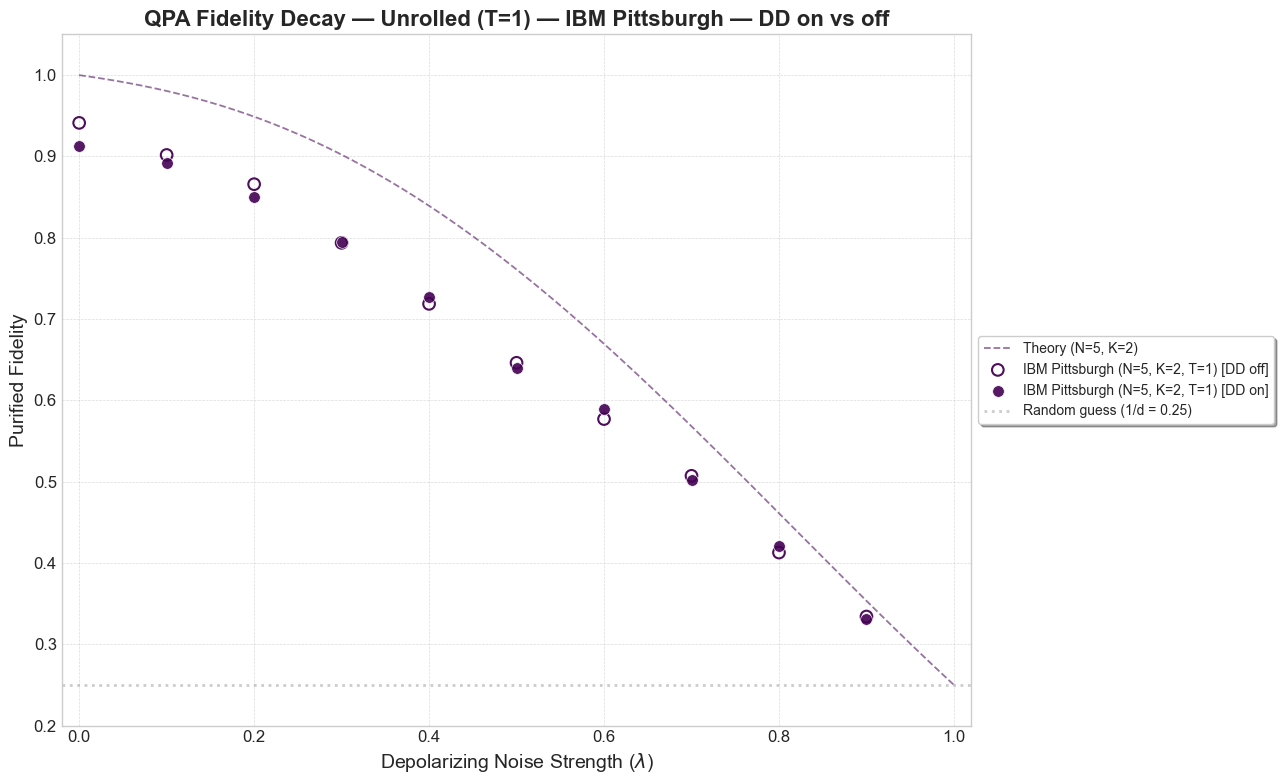

In [9]:
def theory_curve(lam, n, k):
    """Closed-form theory for K=2, available for N=3,5,7."""
    if k == 2:
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
        elif n == 7:
            return (1/215040) * (215040 - 23040*lam - 50688*lam**2 - 88768*lam**3
                                  - 311056*lam**4 + 497192*lam**5 - 207951*lam**6 + 23031*lam**7)
    return None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'lines.linewidth': 2, 'lines.markersize': 7,
})

fig, ax = plt.subplots(figsize=(13, 8))
lam_fine = np.linspace(0, 1, 200)

n_values_sorted = sorted(df_per_exp.keys())
cmap = plt.get_cmap('viridis')
colors = {n: cmap(i / max(1, len(n_values_sorted) - 1)) for i, n in enumerate(n_values_sorted)}
marker_cycle = ['o', '^', 's', 'D', 'v', 'P', 'X', '*', 'h', '<']
markers = {n: marker_cycle[i % len(marker_cycle)] for i, n in enumerate(n_values_sorted)}

# DD style mapping: off = open markers, on = filled markers
dd_style = {
    'off': dict(facecolors='none', edgecolors=None, linewidth=1.5, alpha=0.95, label_suffix=' [DD off]'),
    'on':  dict(facecolors=None,   edgecolors='white', linewidth=0.5, alpha=0.9, label_suffix=' [DD on]'),
}

for n in n_values_sorted:
    th = theory_curve(lam_fine, n, K)
    if th is not None:
        ax.plot(lam_fine, th, '--', color=colors[n], linewidth=1.3, alpha=0.55,
                label=f'Theory (N={n}, K=2)')

    for dd_mode in DD_MODES:
        df = df_per_exp[n].get(dd_mode)
        if df is None or len(df) == 0:
            continue
        style = dd_style[dd_mode]
        face = colors[n] if dd_mode == 'on' else 'none'
        edge = 'white' if dd_mode == 'on' else colors[n]
        ax.scatter(
            df['lambda'], df['fidelity'],
            marker=markers[n], s=70, zorder=5,
            facecolors=face, edgecolors=edge,
            linewidth=style['linewidth'], alpha=style['alpha'],
            label=f'IBM Pittsburgh (N={n}, K=2, T=1){style["label_suffix"]}',
        )

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d = 0.25)')
ax.set_title('QPA Fidelity Decay — Unrolled (T=1) — IBM Pittsburgh — DD on vs off', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=True, shadow=True, ncol=1)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "fidelity_decay_unrolled_t1_ibm_pittsburgh.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

## Step 8: Result Inspection


In [10]:
for n in sorted(df_per_exp):
    for dd_mode in DD_MODES:
        df = df_per_exp[n].get(dd_mode)
        if df is None or len(df) == 0:
            continue
        print(f"\n=== N={n}, K={K}, T={T}, dd={dd_mode} ===")
        print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>12} {'Delta':>10}")
        print("-" * 48)
        for _, row in df.iterrows():
            lam = row['lambda']
            exp_f = row['fidelity']
            th_f = theory_curve(lam, n, K)
            if th_f is not None:
                delta = exp_f - th_f
                print(f"{lam:8.4f} {exp_f:14.4f} {th_f:12.4f} {delta:+10.4f}")
            else:
                print(f"{lam:8.4f} {exp_f:14.4f} {'n/a':>12} {'n/a':>10}")


=== N=5, K=2, T=1, dd=off ===
  Lambda   Exp Fidelity       Theory      Delta
------------------------------------------------
  0.0000         0.9413       1.0000    -0.0587
  0.1000         0.9018       0.9805    -0.0787
  0.2000         0.8659       0.9489    -0.0830
  0.3000         0.7937       0.9022    -0.1084
  0.4000         0.7187       0.8393    -0.1206
  0.5000         0.6462       0.7610    -0.1148
  0.6000         0.5770       0.6695    -0.0925
  0.7000         0.5072       0.5681    -0.0609
  0.8000         0.4128       0.4612    -0.0484
  0.9000         0.3341       0.3534    -0.0193

=== N=5, K=2, T=1, dd=on ===
  Lambda   Exp Fidelity       Theory      Delta
------------------------------------------------
  0.0000         0.9123       1.0000    -0.0877
  0.1000         0.8920       0.9805    -0.0885
  0.2000         0.8507       0.9489    -0.0982
  0.3000         0.7948       0.9022    -0.1074
  0.4000         0.7267       0.8393    -0.1126
  0.5000         0.6399  

## Step 9: Final Consolidated Save

Per-(N, dd) CSV/JSON files are already written incrementally during the sweep. This step combines them into a single consolidated CSV + JSON for convenience.


In [11]:
combined_rows = []
for n in sorted(df_per_exp):
    for dd_mode in DD_MODES:
        df = df_per_exp[n].get(dd_mode)
        if df is None or len(df) == 0:
            continue
        for _, row in df.iterrows():
            lam = float(row['lambda'])
            exp_f = float(row['fidelity'])
            th_f = theory_curve(lam, n, K)
            combined_rows.append({
                'n': n, 'k': K, 't': T,
                'dd_mode': dd_mode,
                'lambda': lam,
                'fidelity_experiment': exp_f,
                'fidelity_theory': float(th_f) if th_f is not None else None,
                'delta': (exp_f - float(th_f)) if th_f is not None else None,
                'job_ids': row.get('job_ids', ''),
                'n_batches': row.get('n_batches', None),
            })

combined_df = pd.DataFrame(combined_rows)

combined_csv = os.path.join(RESULTS_DIR, "results_all_unrolled_ibm_pittsburgh.csv")
combined_json = os.path.join(RESULTS_DIR, "results_all_unrolled_ibm_pittsburgh.json")

combined_df.to_csv(combined_csv, index=False)

run_meta = {
    'backend': backend.name,
    'k': K, 't': T,
    'n_values': sorted(df_per_exp.keys()),
    'dd_modes': DD_MODES,
    'dd_sequence': DD_SEQUENCE,
    'dd_skip_reset_qubits': DD_SKIP_RESET_QUBITS,
    'lambdas': lambdas.tolist(),
    'n_random': N_RANDOM,
    'shots_per_circuit': SHOTS,
    'batch_size': BATCH_SIZE,
    'transpile_seeds': TRANSPILE_SEEDS,
    'opt_level': OPT_LEVEL,
    'job_tags_project': 'QPA',
}
with open(combined_json, 'w') as f:
    json.dump({'meta': run_meta, 'results': combined_rows}, f, indent=2)

print(f"Combined CSV  -> {combined_csv}")
print(f"Combined JSON -> {combined_json}")
combined_df

Combined CSV  -> data/results/end_to_end_unrolled_pittsburgh_t1/results_all_unrolled_ibm_pittsburgh.csv
Combined JSON -> data/results/end_to_end_unrolled_pittsburgh_t1/results_all_unrolled_ibm_pittsburgh.json


,n,k,t,dd_mode,lambda,fidelity_experiment,fidelity_theory,delta,job_ids,n_batches
0,5,2,1,off,0.0,0.941267,1.000000,-0.058733,"d82q9p7tjchs73bod9qg,d82qcfegbeec73am5490,d82q...",4
1,5,2,1,off,0.1,0.901800,0.980512,-0.078712,"d82qr1ftjchs73bodt20,d82qs9noha1c73blu86g,d82q...",4
2,5,2,1,off,0.2,0.865867,0.948906,-0.083039,"d82r0g7oha1c73blud40,d82r1r80bvlc73d2lodg,d82r...",4
3,5,2,1,off,0.3,0.793733,0.902159,-0.108425,"d82r5mfoha1c73bluj90,d82r75foha1c73bluktg,d82r...",4
4,5,2,1,off,0.4,0.718667,0.839272,-0.120605,"d82rb16gbeec73am68k0,d82rc9o0bvlc73d2m4mg,d82r...",4
5,5,2,1,off,0.5,0.646200,0.760986,-0.114786,"d82rg2vtjchs73boelk0,d82rjh80bvlc73d2mdgg,d82r...",4
6,5,2,1,off,0.6,0.577000,0.669493,-0.092493,"d82rnjugbeec73am6otg,d82rot6gbeec73am6qg0,d82r...",4
7,5,2,1,off,0.7,0.507200,0.568148,-0.060948,"d82s7lnoha1c73blvung,d82s8tegbeec73am7go0,d82t...",4
8,5,2,1,off,0.8,0.412800,0.461184,-0.048384,"d82ttafoha1c73bm1tag,d82tul80bvlc73d2p95g",4
9,5,2,1,off,0.9,0.334133,0.353426,-0.019292,"d82utt6gbeec73amak30,d82v3nmgbeec73amat60,d82v...",4
